# TELL load forecast data flow and 2023 validation

Develop a MISO TELL model using 2019-2022 actual load and historical weather, predict
2007-2023 load, and validate against held-out 2023 actual load.

**Inputs:** Raw EIA-930 load, packaged BA weather, BA metadata, and weather-source periods.
**Outputs:** Training and prediction CSVs, calibration scores, reusable model files,
forecasts, validation metrics, and figures under `data_outputs/data_flow/tell_load_forecast_data_flow/`.
Model calibration and training require TELL; they are separate from the final validation.

1. **Prepare inputs (Steps 1-5):** Clean load, build predictors, and write the training CSV.
2. **Calibrate and train (Steps 6-8):** Compare MLP candidates and save the selected model.
3. **Predict (Steps 9-10):** Prepare yearly weather inputs and generate hourly forecasts.
4. **Validate (Step 11):** Compare the held-out 2023 forecast with actual load.


## Setup

Load the libraries used below and point directly to the packaged data and notebook scratch-output folders.


In [1]:
from IPython.display import display
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar

# Fixed MISO inputs; the notebook generates its own load forecast.
raw_actual_csv = Path("../../data_inputs/load_actuals/raw/MISO_hourly_load.csv")
OUTPUT_DIR = Path("../../data_outputs/data_flow/tell_load_forecast_data_flow")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Step 1: Select BA metadata

This step selects the `BA_CODE` (`MISO` in this example) and reads the packaged BA metadata (`BA_ID` and `BA_NAME`). Note that TELL uses the EIA balancing-authority number (`BA_ID`) as its region identifier.


In [2]:
BA_CODE = "MISO"

ba_metadata = pd.read_csv("../../data_inputs/validation/load_forecast/ba_2023_validation_metadata.csv", dtype={"BA_CODE": str, "BA_ID": str},)
ba_row = ba_metadata.loc[ba_metadata["BA_CODE"].eq(BA_CODE)].iloc[0]
BA_ID = str(ba_row["BA_ID"])

display(pd.DataFrame([
    {"setting": "BA_CODE", "value": BA_CODE},
    {"setting": "BA_ID", "value": BA_ID},
    {"setting": "BA_NAME", "value": str(ba_row["BA_NAME"])},
]).rename(columns={"setting": "Setting", "value": "Value"}).set_index("Setting"))

,Value
Setting,
BA_CODE,MISO
BA_ID,56669
BA_NAME,"Midcontinent Independent System Operator, Inc."


## Step 2: Load raw EIA-930 actual load

EIA-930 actual-load data is packaged under `data_inputs/load_actuals/raw`.


In [3]:
# Read raw EIA-930 actual load so the cleaning method can be reviewed.
raw_actual = pd.read_csv(raw_actual_csv, usecols=["Time_UTC", "Load"])
raw_actual = raw_actual.rename(columns={"Time_UTC": "time_utc", "Load": "load_actual_mw_raw"})
raw_actual["time_utc"] = pd.to_datetime(raw_actual["time_utc"], utc=True)
raw_actual["load_actual_mw_raw"] = pd.to_numeric(raw_actual["load_actual_mw_raw"])

display(raw_actual.head())
print(f"Read {len(raw_actual):,} raw actual-load rows: {raw_actual_csv.as_posix()}")

,time_utc,load_actual_mw_raw
0,2019-01-01 00:00:00+00:00,74304.0
1,2019-01-01 01:00:00+00:00,73391.0
2,2019-01-01 02:00:00+00:00,71531.0
3,2019-01-01 03:00:00+00:00,69562.0
4,2019-01-01 04:00:00+00:00,67744.0


Read 43,824 raw actual-load rows: ../../data_inputs/load_actuals/raw/MISO_hourly_load.csv


## Step 3: Clean missing, nonpositive, and same-hour outlier load

This step applies the cleaning logic to the raw EIA-930 input and creates `cleaned_actuals`, the table used below for TELL training and 2023 validation. This cleaning step applies two rules:

1. Invalid load rule: missing, zero, or negative load is set to missing.
2. Same-hour outlier rule: each load value is compared with a centered rolling median of seven observations at the same local clock hour (normally seven days). The median is calculated when at least five valid same-hour observations are available. Values differing from this median by 40% or more are removed.

After cleaning, the notebook keeps the 2019-2023 rows used for 2019-2022 model training and 2023 model validation.

In [4]:
DEVELOPMENT_YEARS = [2019, 2020, 2021, 2022]
VALIDATION_YEAR = 2023
LOCAL_TIMEZONE = "America/Chicago"

load_cleaning = raw_actual.sort_values("time_utc").reset_index(drop=True)
load_cleaning["year"] = load_cleaning["time_utc"].dt.year
load_cleaning["local_clock_hour"] = load_cleaning["time_utc"].dt.tz_convert(LOCAL_TIMEZONE).dt.hour

# Rule 1: remove missing, zero, or negative load.
load_cleaning["load_flag_missing_nonpositive"] = (
    load_cleaning["load_actual_mw_raw"].isna()
    | load_cleaning["load_actual_mw_raw"].le(0)
)
load_cleaning["load_actual_mw_clean"] = load_cleaning["load_actual_mw_raw"].mask(
    load_cleaning["load_flag_missing_nonpositive"]
)

# Rule 2: remove values at least 40% away from the same-hour median.
# Calculate the rolling median of nearby days at the same local clock hour.
load_cleaning["same_hour_median_baseline_mw"] = np.nan
for clock_hour in range(24):
    same_hour_rows = load_cleaning["local_clock_hour"].eq(clock_hour)
    load_cleaning.loc[same_hour_rows, "same_hour_median_baseline_mw"] = (
        load_cleaning.loc[same_hour_rows, "load_actual_mw_clean"]
        .rolling(window=7, center=True, min_periods=5)
        .median()
    )

# Flag deviations of at least 40% from that baseline.
pct_diff_from_baseline = (
    load_cleaning["load_actual_mw_clean"] - load_cleaning["same_hour_median_baseline_mw"]
).abs() / load_cleaning["same_hour_median_baseline_mw"].abs()
load_cleaning["load_flag_same_hour_outlier"] = pct_diff_from_baseline.ge(0.40).fillna(False)
load_cleaning["load_actual_mw_clean"] = load_cleaning["load_actual_mw_clean"].mask(
    load_cleaning["load_flag_same_hour_outlier"]
)

# Keep the actual-load years used for TELL training and held-out validation.
cleaned_actual_columns = ["time_utc", "load_actual_mw_clean"]
cleaned_actuals = load_cleaning.loc[
    load_cleaning["year"].isin(DEVELOPMENT_YEARS + [VALIDATION_YEAR]),
    cleaned_actual_columns,
].reset_index(drop=True)

cleaning_summary = pd.DataFrame([
    {"cleaning_step": "raw rows", "count": len(load_cleaning)},
    {"cleaning_step": "missing or nonpositive load values",
     "count": int(load_cleaning["load_flag_missing_nonpositive"].sum())},
    {"cleaning_step": "same-hour 40 pct outliers",
     "count": int(load_cleaning["load_flag_same_hour_outlier"].sum())},
    {"cleaning_step": "remaining missing cleaned load",
     "count": int(cleaned_actuals["load_actual_mw_clean"].isna().sum())},
    {"cleaning_step": "non-Nan cleaned load values",
     "count": int(cleaned_actuals["load_actual_mw_clean"].notna().sum()),
}
])
display(
    cleaning_summary.rename(
        columns={"cleaning_step": "Cleaning step", "count": "Rows"}
    ).set_index("Cleaning step")
)


,Rows
Cleaning step,
raw rows,43824
missing or nonpositive load values,11
same-hour 40 pct outliers,0
remaining missing cleaned load,11
non-Nan cleaned load values,43813


## Step 4: Build weather and calendar predictors

The below table shows the predictor variables, organized by category. 


| Predictor group | Raw input column(s) | Model feature column(s) |
|---|---|---|
| direct weather predictors | packaged BA-weather columns | `temperature_2m`, `windspeed_10m`, `ghi` |
| local daily cycle | `time_utc` converted to local hour | `Hour_sin`, `Hour_cos` |
| local seasonal cycle | `time_utc` converted to local day of year | `DOY_sin`, `DOY_cos` |
| local weekly cycle | `time_utc` converted to local day of week | `DOW_sin`, `DOW_cos` |
| federal holiday | local date | `IsHoliday` |
| degree response | `temperature_2m` | `CoolDegC`, `HeatDegC` |
| temperature memory | `temperature_2m` grouped by `load_weather_source` | `temperature_2m_roll_mean_24h`, `temperature_2m_roll_mean_72h` |


*Notes*:

-  Rolling temperature predictors carry across years within the same `load_weather_source` and reset when `load_weather_source` changes. For this example, they carry across 2007-2014 for `wtk_nsrdb`, then reset at the start of 2015 for `bchrrr_nsrdb`.

- Population is excluded because the assumption is fixed across the training period. A future extension could add a time-varying annual population predictor to both training and prediction inputs.

- Specific humidity and its temperature interaction are excluded because faulty historical WTK humidity values produced unrealistic load predictions. They are not computed in this example.

In [5]:
PREDICTOR_COLUMNS = [
    # Direct weather variables from BCHRRR/WTK/NSRDB.
    "temperature_2m",       # air temperature
    "windspeed_10m",        # wind speed
    "ghi",                  # sunlight/irradiance

    # Local-time calendar variables.
    "Hour_sin",             # hour of day cycle
    "Hour_cos",             # hour of day cycle
    "DOY_sin",              # day of year cycle
    "DOY_cos",              # day of year cycle
    "DOW_sin",              # day of week cycle
    "DOW_cos",              # day of week cycle
    "IsHoliday",            # federal holiday flag

    # Derived weather variables used by the archived TELL workflow.
    "CoolDegC",             # cooling-degree response above 18 C
    "HeatDegC",             # heating-degree response below 18 C
    "temperature_2m_roll_mean_24h",          # 24-hour rolling temperature mean
    "temperature_2m_roll_mean_72h",          # 72-hour rolling temperature mean
]


# Read the weather-source period table that documents the combined weather bundle.
source_periods = pd.read_csv("../../data_inputs/model_parameters/load_weather_source_periods_2007_2023.csv")
source_periods = source_periods.loc[source_periods["source_bundle"].eq("wtk_bchrrr_nsrdb")]
display(source_periods)

# Read only the packaged BA-weather columns used by the model.
feature_variables = pd.read_csv(
    "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_weather/MISO_wtk_bchrrr_nsrdb_2007_2023_weather.csv",
    usecols=["time_utc", "temperature_2m", "windspeed_10m", "ghi"],
).rename(columns={"time_utc": "Time_UTC"})
feature_variables["Time_UTC"] = pd.to_datetime(feature_variables["Time_UTC"], utc=True)
feature_variables = feature_variables.sort_values("Time_UTC").reset_index(drop=True)
feature_variables["year"] = feature_variables["Time_UTC"].dt.year

# Assign each weather row to the load-weather-source period documented above.
feature_variables["load_weather_source"] = pd.NA
for _, source_period in source_periods.iterrows():
    years_in_period = feature_variables["year"].between(int(source_period["start_year"]), int(source_period["end_year"]))
    feature_variables.loc[years_in_period, "load_weather_source"] = source_period["load_weather_source"]

if feature_variables["load_weather_source"].isna().any():
    raise ValueError("Some weather rows were not assigned to a documented load_weather_source weather-source period.")

,source_bundle,source_window_index,start_year,end_year,load_weather_source,wind_source,solar_source
0,wtk_bchrrr_nsrdb,1,2007,2014,wtk_nsrdb,wtk,nsrdb
1,wtk_bchrrr_nsrdb,2,2015,2023,bchrrr_nsrdb,bchrrr,nsrdb


### Calendar and weather-response predictors

The preview shows all 14 predictors and their weather source for two hours, one with zero and one with positive solar irradiance. The column headings are UTC timestamps.


In [6]:
# Add UTC fields for joins and local fields for TELL-style calendar predictors.
stamp_utc = feature_variables["Time_UTC"]
stamp_local = stamp_utc.dt.tz_convert(LOCAL_TIMEZONE)
feature_variables["Year"] = stamp_local.dt.year
feature_variables["Month"] = stamp_local.dt.month
feature_variables["Day"] = stamp_local.dt.day
feature_variables["Hour"] = stamp_local.dt.hour


# Add daily, seasonal, and weekly cycles.
hour = stamp_local.dt.hour.astype(float)
day_of_year = stamp_local.dt.dayofyear.astype(float)
day_of_week = stamp_local.dt.dayofweek.astype(float)
feature_variables["Hour_sin"] = np.sin(2.0 * np.pi * hour / 24.0)
feature_variables["Hour_cos"] = np.cos(2.0 * np.pi * hour / 24.0)
feature_variables["DOY_sin"] = np.sin(2.0 * np.pi * day_of_year / 365.25)
feature_variables["DOY_cos"] = np.cos(2.0 * np.pi * day_of_year / 365.25)
feature_variables["DOW_sin"] = np.sin(2.0 * np.pi * day_of_week / 7.0)
feature_variables["DOW_cos"] = np.cos(2.0 * np.pi * day_of_week / 7.0)

# Add holiday and non-rolling weather predictors.
holidays = USFederalHolidayCalendar().holidays(start=stamp_local.min().normalize(), end=stamp_local.max().normalize())
feature_variables["IsHoliday"] = stamp_local.dt.normalize().isin(holidays).astype(int)
feature_variables["CoolDegC"] = (feature_variables["temperature_2m"] - 18.0).clip(lower=0.0)
feature_variables["HeatDegC"] = (18.0 - feature_variables["temperature_2m"]).clip(lower=0.0)

# Rolling means carry across years within a weather source, but reset when load_weather_source
# changes.
temperature_by_source = feature_variables.groupby("load_weather_source", sort=False)["temperature_2m"]
for hours in (24, 72):
    feature_variables[f"temperature_2m_roll_mean_{hours}h"] = temperature_by_source.transform(lambda values: values.rolling(hours, min_periods=1).mean())
display(
    feature_variables.set_index("Time_UTC").loc[
        pd.to_datetime(["2007-01-01 00:00", "2007-01-01 18:00"], utc=True),
        ["load_weather_source"] + PREDICTOR_COLUMNS,
    ].T
)

,2007-01-01 00:00:00+00:00,2007-01-01 18:00:00+00:00
load_weather_source,wtk_nsrdb,wtk_nsrdb
temperature_2m,6.888647,3.740909
windspeed_10m,4.261637,4.980544
ghi,0.0,347.391897
Hour_sin,-1.0,0.0
Hour_cos,-0.0,-1.0
DOY_sin,-0.004301,0.017202
DOY_cos,0.999991,0.999852
DOW_sin,-0.781831,0.0
DOW_cos,0.62349,1.0


## Step 5: Build the TELL training table

This step formats the historical data for TELL's BA-level multilayer perceptron (MLP) model. As described in the [TELL User Guide](https://immm-sfa.github.io/tell/user_guide.html#multilayer-perceptron-mlp-models), TELL trains a separate MLP for each BA using historical hourly electricity demand and weather.

For this MISO example, the code:

- aligns cleaned EIA-930 load (`Load`) with the Step 4 weather and calendar predictors using the exact UTC timestamp (`Time_UTC`);
- keeps the `2019-2022` development years and excludes rows that lack the load target or a predictor; and
- writes `56669_training.csv`, required by the file-based `tell.mlp_train.train()` interface for both calibration and final training.

The training CSV contains one retained hour per row, with `Time_UTC` for auditing the load-weather alignment, the local `Year`, `Month`, `Day`, and `Hour` fields read by TELL, the cleaned load target, and the predictor columns. `PREDICTOR_COLUMNS` is passed directly to TELL through `x_variables`; no separate predictor-list file is needed. Applying an already-trained model does not require the training CSV.

The lowercase `year` column is used internally to select development and prediction years but is not written to the TELL files. TELL training reads the uppercase local-time fields, while TELL prediction reads `Time_UTC`. `LOCAL_TIMEZONE` is set explicitly for this MISO example.

In [7]:
training_dir = OUTPUT_DIR / "tell" / BA_CODE / BA_ID / "training"
training_dir.mkdir(parents=True, exist_ok=True)

# Use the feature-variable table from Step 4, then keep only the 2019-2022 rows for training
training_features = feature_variables.loc[feature_variables["year"].isin(DEVELOPMENT_YEARS)]

# One explicit UTC merge aligns the cleaned target with the predictor rows.
tell_frame = training_features.merge(
    cleaned_actuals[["time_utc", "load_actual_mw_clean"]].rename(
        columns={"time_utc": "Time_UTC", "load_actual_mw_clean": "Load"}
    ),
    on="Time_UTC", how="left", validate="one_to_one",
)

training_time_columns = ["Time_UTC", "Year", "Month", "Day", "Hour"]
training_columns = training_time_columns + ["Load"] + PREDICTOR_COLUMNS

model_training = tell_frame[training_columns].dropna(subset=PREDICTOR_COLUMNS + ["Load"])

# Write the native TELL training file with timestamp strings in the format TELL reads.
native_training_csv = training_dir / f"{BA_ID}_training.csv"

model_training.to_csv(native_training_csv, index=False, date_format="%Y-%m-%d %H:%M:%S")

print(f"Wrote training CSV: {native_training_csv.as_posix()}")
print(f"Training rows: {len(model_training):,}; predictors: {len(PREDICTOR_COLUMNS)}.")


Wrote training CSV: ../../data_outputs/data_flow/tell_load_forecast_data_flow/tell/MISO/56669/training/56669_training.csv
Training rows: 35,053; predictors: 14.


## Step 6: Define the TELL MLP calibration design

This step defines the MLP settings and seasonal validation windows used to choose the final TELL model. 

The notebook tests five MLP candidates. Each candidate has a different `mlp_hidden_layer_sizes` and `mlp_max_iter`. The notebook tests each candidate against four 30-day validation windows: spring, summer, autumn, and winter. Each window is 720 hours, and the window starts are spaced 90 days apart.

In TELL, `split_datetime` is the last timestamp included in the training period. The validation window starts one hour later at `validation_start` and ends at `validation_end`.

The code pairs every MLP candidate with every seasonal validation window. The resulting `calibration_runs` table has one row for each temporary model that Step 7 trains and scores.

In [8]:
tell_train_options = {
    "x_variables": PREDICTOR_COLUMNS,          # predictors TELL reads from the training CSV
    "y_variables": ["Load"],                  # target column TELL learns to predict
    "add_dayofweek_xvars": False,             # DOW_sin and DOW_cos are already included
    "seed_value": 391,                        # packaged archive and TELL default seed
    "mlp_validation_fraction": 0.10,          # TELL's internal validation split inside each window
}

mlp_candidates = pd.DataFrame(
    [
        {"mlp_hidden_layer_sizes": 150, "mlp_max_iter": 1500},
        {"mlp_hidden_layer_sizes": 300, "mlp_max_iter": 2000},
        {"mlp_hidden_layer_sizes": 600, "mlp_max_iter": 2500},
        {"mlp_hidden_layer_sizes": 1200, "mlp_max_iter": 3000},
        {"mlp_hidden_layer_sizes": 2000, "mlp_max_iter": 4000},
    ]
)
CALIBRATION_TRAIN_START = "2019-01-01 00:00:00"

seasonal_validation_windows = pd.DataFrame(
    [
        {"season": "spring", "split_datetime": "2022-03-06 23:00:00", "validation_start": "2022-03-07 00:00:00", "validation_end": "2022-04-05 23:00:00"},
        {"season": "summer", "split_datetime": "2022-06-04 23:00:00", "validation_start": "2022-06-05 00:00:00", "validation_end": "2022-07-04 23:00:00"},
        {"season": "autumn", "split_datetime": "2022-09-02 23:00:00", "validation_start": "2022-09-03 00:00:00", "validation_end": "2022-10-02 23:00:00"},
        {"season": "winter", "split_datetime": "2022-12-01 23:00:00", "validation_start": "2022-12-02 00:00:00", "validation_end": "2022-12-31 23:00:00"},
    ]
)

# `split_datetime` is the training-period end; validation begins the next hour.
# Cross join: run every candidate MLP size in every seasonal validation window.
calibration_runs = seasonal_validation_windows.merge(mlp_candidates, how="cross")

display(
    mlp_candidates.rename(columns={'mlp_hidden_layer_sizes': 'Hidden units', 'mlp_max_iter': 'Maximum iterations'})
)
display(
    seasonal_validation_windows.rename(columns={'season': 'Season',
     'split_datetime': 'Last training hour',
     'validation_start': 'First validation hour',
     'validation_end': 'Last validation hour'}).set_index('Season')
)


,Hidden units,Maximum iterations
0,150,1500
1,300,2000
2,600,2500
3,1200,3000
4,2000,4000


,Last training hour,First validation hour,Last validation hour
Season,,,
spring,2022-03-06 23:00:00,2022-03-07 00:00:00,2022-04-05 23:00:00
summer,2022-06-04 23:00:00,2022-06-05 00:00:00,2022-07-04 23:00:00
autumn,2022-09-02 23:00:00,2022-09-03 00:00:00,2022-10-02 23:00:00
winter,2022-12-01 23:00:00,2022-12-02 00:00:00,2022-12-31 23:00:00


## Step 7A: Run the calibration

Each row of `calibration_runs` trains one temporary TELL model for one MLP candidate and one seasonal validation window. The 20 runs appear in four seasonal groups, with five candidates per group. Each group shows its training and validation dates; each run prints its settings before training and its `RMS_NORM` score when complete.

Calibration is performed separately for each `BA_CODE` in the operational data flow, so different BAs may select different MLP candidates.


In [9]:
from tell.mlp_train import train

print(f"Calibrating {len(calibration_runs)} MLP candidate/season combinations.")
rms_norm_values = []
previous_season = None
for run_number, run in enumerate(calibration_runs.to_dict("records"), start=1):
    if run["season"] != previous_season:
        print(f"\n{run['season'].upper()}")
        print(f"Training: {CALIBRATION_TRAIN_START} through {run['split_datetime']}")
        print(f"Validation: {run['validation_start']} through {run['validation_end']}")
        previous_season = run["season"]

    print(
        f"\nRun {run_number}/{len(calibration_runs)} | "
        f"hidden size: {run['mlp_hidden_layer_sizes']} | max iterations: {run['mlp_max_iter']}",
        flush=True,
    )
    # TELL call 1: train one temporary model for one candidate and one validation window.
    _, stats = train(
        BA_ID,
        str(training_dir),
        **tell_train_options,
        start_time=CALIBRATION_TRAIN_START,
        split_datetime=run["split_datetime"],
        end_time=run["validation_end"],
        mlp_hidden_layer_sizes=int(run["mlp_hidden_layer_sizes"]),
        mlp_max_iter=int(run["mlp_max_iter"]),
    )
    rms_norm_values.append(float(stats.iloc[0]["RMS_NORM"]))
    print(f"Completed: RMS_NORM = {rms_norm_values[-1]:.6f}", flush=True)

C:\Users\charl\miniconda3\envs\wxdata\lib\site-packages\tell\package_data.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Calibrating 20 MLP candidate/season combinations.

SPRING
Training: 2019-01-01 00:00:00 through 2022-03-06 23:00:00
Validation: 2022-03-07 00:00:00 through 2022-04-05 23:00:00

Run 1/20 | hidden size: 150 | max iterations: 1500
Completed: RMS_NORM = 0.021029

Run 2/20 | hidden size: 300 | max iterations: 2000
Completed: RMS_NORM = 0.020124

Run 3/20 | hidden size: 600 | max iterations: 2500
Completed: RMS_NORM = 0.020223

Run 4/20 | hidden size: 1200 | max iterations: 3000
Completed: RMS_NORM = 0.020115

Run 5/20 | hidden size: 2000 | max iterations: 4000
Completed: RMS_NORM = 0.021186

SUMMER
Training: 2019-01-01 00:00:00 through 2022-06-04 23:00:00
Validation: 2022-06-05 00:00:00 through 2022-07-04 23:00:00

Run 6/20 | hidden size: 150 | max iterations: 1500
Completed: RMS_NORM = 0.033003

Run 7/20 | hidden size: 300 | max iterations: 2000
Completed: RMS_NORM = 0.029737

Run 8/20 | hidden size: 600 | max iterations: 2500
Completed: RMS_NORM = 0.041317

Run 9/20 | hidden size: 1200 | 

## Step 7B: Compare candidates and select the model

After all 20 runs in Step 7A finish, average each candidate's `RMS_NORM` across the four seasonal windows and select the candidate with the lowest mean. The table shows all four seasonal scores beside that mean. Selection uses unrounded
values; displayed NRMSE is a fraction, normalized by each window's mean actual load.

`MISO_mlp_tuning.csv` records the calibration results and documents model selection; it is not an input to prediction. This comparison cell can be rerun using the completed Step 7A results in the current kernel without retraining the candidates.


In [2]:
tuning_dir = OUTPUT_DIR / "tell" / BA_CODE / BA_ID / "tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

# Average each candidate's seasonal-window scores and select the lowest-error candidate.
tuning = calibration_runs.copy()
tuning["RMS_NORM"] = rms_norm_values
tuning.to_csv(tuning_dir / f"{BA_CODE}_mlp_tuning.csv", index=False)

tuning_summary = (
    tuning.groupby(["mlp_hidden_layer_sizes", "mlp_max_iter"], as_index=False)["RMS_NORM"]
    .mean()
    .rename(columns={"RMS_NORM": "mean_RMS_NORM"})
    .sort_values("mean_RMS_NORM")
)
selected_row = tuning_summary.iloc[0]
selected_candidate = {
    "mlp_hidden_layer_sizes": int(selected_row["mlp_hidden_layer_sizes"]),
    "mlp_max_iter": int(selected_row["mlp_max_iter"]),
}

# Show all four seasonal scores beside the unchanged mean used for selection.
seasonal_scores = tuning.pivot(
    index=["mlp_hidden_layer_sizes", "mlp_max_iter"],
    columns="season", values="RMS_NORM",
)[["spring", "summer", "autumn", "winter"]]
display(
    tuning_summary.join(
        seasonal_scores, on=["mlp_hidden_layer_sizes", "mlp_max_iter"]
    ).rename(columns={'mlp_hidden_layer_sizes': 'Hidden units',
     'mlp_max_iter': 'Maximum iterations',
     'mean_RMS_NORM': 'Mean seasonal NRMSE',
     'spring': 'Spring',
     'summer': 'Summer',
     'autumn': 'Autumn',
     'winter': 'Winter'}).set_index(['Hidden units', 'Maximum iterations']).round(3)
)
print(
    f"Selected MLP: hidden size {selected_candidate['mlp_hidden_layer_sizes']} | "
    f"max iterations {selected_candidate['mlp_max_iter']}."
)
print(f"Wrote {len(tuning):,} calibration scores: {(tuning_dir / f'{BA_CODE}_mlp_tuning.csv').as_posix()}")


,,Mean seasonal NRMSE,Spring,Summer,Autumn,Winter
Hidden units,Maximum iterations,,,,,
2000,4000,0.026,0.021,0.026,0.021,0.035
150,1500,0.027,0.021,0.033,0.021,0.033
1200,3000,0.028,0.020,0.032,0.023,0.038
300,2000,0.029,0.020,0.030,0.025,0.040
600,2500,0.029,0.020,0.041,0.022,0.034


Selected MLP: hidden size 2000 | max iterations 4000.
Wrote 20 calibration scores: ../../data_outputs/data_flow/tell_load_forecast_data_flow/tell/MISO/56669/tuning/MISO_mlp_tuning.csv


## Step 8: Train the final TELL model

Steps 6-7 selected the MLP settings (`mlp_hidden_layer_sizes` and `mlp_max_iter`) using four seasonal 2022 validation windows. This step runs the final TELL training call with those selected settings.

TELL still requires a `split_datetime` inside the data passed to `train()`. Rows through `split_datetime` are used to fit the saved model. Rows after `split_datetime`, the final 30 days of 2022, are used only as TELL's internal test period.

This internal 2022 test period is separate from the notebook validation. The notebook validation happens later in Step 11 and uses 2023 actual load only.

This step saves two reusable `.joblib` files: the fitted scikit-learn MLP and the normalization dictionary used to scale its inputs and convert its predictions back to MW. Both files are required for prediction.

**TELL internal test statistics:** The displayed library-returned statistics describe
that internal 2022 test window. They remain separate from the notebook-defined,
held-out 2023 metrics in Step 11.


In [10]:
model_dir = OUTPUT_DIR / "load_models" / BA_CODE / BA_ID
model_dir.mkdir(parents=True, exist_ok=True)

final_train_start = model_training["Time_UTC"].min()
final_train_end = model_training["Time_UTC"].max()
final_split = final_train_end - pd.Timedelta(days=30)

# TELL call 2: train the selected final model on the 2019-2022 development period.
_, final_training_stats = train(
    BA_ID,
    str(training_dir),
    **tell_train_options,
    start_time=final_train_start.strftime("%Y-%m-%d %H:%M:%S"),
    split_datetime=final_split.strftime("%Y-%m-%d %H:%M:%S"),
    end_time=final_train_end.strftime("%Y-%m-%d %H:%M:%S"),
    save_model=True,
    model_output_directory=str(model_dir),
    **selected_candidate,
)

display(final_training_stats)


,BA,RMS_ABS,RMS_NORM,MAPE,R2
0,56669,2618.663701,0.034744,0.029973,0.91105


## Step 9: Build yearly TELL prediction-weather tables

This step converts the Step 4 weather and calendar predictor dataframe into the yearly CSV files required by TELL's `predict()` API. TELL does not read the in-memory `feature_variables` dataframe directly.

The notebook writes one CSV for each prediction year from 2007 through 2023. Each file contains `Time_UTC` and the Step 4 predictor columns; it does not include actual load or separate year, month, day, and hour columns.

The exact filename pattern is `{BA_ID}_weather_{prediction_year}.csv`. Step 10 reads these files when `predict()` is called. The summary below shows the year range, file count, and row-count range instead of listing every file.


In [11]:
prediction_dir = OUTPUT_DIR / "tell" / BA_CODE / BA_ID / "prediction"
prediction_dir.mkdir(parents=True, exist_ok=True)

PREDICTION_YEARS = list(range(2007, 2024))
prediction_columns = ["Time_UTC"] + PREDICTOR_COLUMNS

prediction_weather_row_counts = []

for prediction_year in PREDICTION_YEARS:
    # Select this target year from the Step 4 feature-variable table.
    prediction_weather_frame = feature_variables.loc[
        feature_variables["year"].eq(prediction_year), prediction_columns
    ].dropna(subset=PREDICTOR_COLUMNS)

    # Write only the target-year rows to the native TELL predictor file.
    native_prediction_path = prediction_dir / f"{BA_ID}_weather_{prediction_year}.csv"
    prediction_weather_frame.to_csv(native_prediction_path, index=False, date_format="%Y-%m-%d %H:%M:%S")
    prediction_weather_row_counts.append(len(prediction_weather_frame))

print(
    f"Wrote {len(PREDICTION_YEARS)} prediction-weather CSVs for "
    f"{min(PREDICTION_YEARS)}-{max(PREDICTION_YEARS)}: "
    f"{(prediction_dir / f'{BA_ID}_weather_{{year}}.csv').as_posix()}"
)
print(
    f"Rows per file: {min(prediction_weather_row_counts):,}-"
    f"{max(prediction_weather_row_counts):,}."
)


Wrote 17 prediction-weather CSVs for 2007-2023: ../../data_outputs/data_flow/tell_load_forecast_data_flow/tell/MISO/56669/prediction/56669_weather_{year}.csv
Rows per file: 8,760-8,784.


## Step 10: Predict 2007-2023 load

This step calls TELL's `predict()` function once for each yearly prediction-weather CSV written in Step 9. For each year, TELL reads `{BA_ID}_weather_{prediction_year}.csv` from `prediction_dir` and applies the saved model from Step 8.

The notebook converts each yearly TELL output into `time_utc` and `load_mw`, stacks all years from 2007 through 2023 into one dataframe, and writes the full notebook-generated forecast CSV.


In [12]:
from tell.mlp_predict import predict

notebook_forecast_csv = OUTPUT_DIR / "MISO_wtk_bchrrr_nsrdb_2007_2023_notebook_load_forecast.csv"

forecast_frames = []
for prediction_year in PREDICTION_YEARS:
    # TELL call 3: predict one target year from that year's native prediction-weather file.
    prediction = predict(
        BA_ID,
        prediction_year,
        str(prediction_dir),
        model_output_directory=str(model_dir),
        x_variables=PREDICTOR_COLUMNS,
        add_dayofweek_xvars=False,
    )

    yearly_forecast = pd.DataFrame(
        {
            "time_utc": pd.to_datetime(prediction["Time_UTC"], utc=True),
            "load_mw": pd.to_numeric(prediction["Load"]),
        }
    )
    forecast_frames.append(yearly_forecast)

notebook_forecast = pd.concat(forecast_frames, ignore_index=True).sort_values("time_utc").reset_index(drop=True)
notebook_forecast.to_csv(notebook_forecast_csv, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")

print(f"Wrote {len(notebook_forecast):,} forecast hours: {notebook_forecast_csv.as_posix()}")
display(notebook_forecast.head())


Wrote 149,016 forecast hours: ../../data_outputs/data_flow/tell_load_forecast_data_flow/MISO_wtk_bchrrr_nsrdb_2007_2023_notebook_load_forecast.csv


,time_utc,load_mw
0,2007-01-01 00:00:00+00:00,71102.71
1,2007-01-01 01:00:00+00:00,72102.05
2,2007-01-01 02:00:00+00:00,71748.53
3,2007-01-01 03:00:00+00:00,70095.67
4,2007-01-01 04:00:00+00:00,67768.04


### Apply the trained model to sup3rCC weather

The trained model can also be applied to sup3rCC weather without retraining. Historical weather is needed for model training because every hourly predictor row must align with the corresponding hourly EIA-930 load observation. To apply the resulting model to sup3rCC, transform the sup3rCC weather into the identical predictor columns constructed in Step 4, write the yearly prediction-weather CSVs in the Step 9 format, and call `predict()` as shown in Step 10 using the MLP and normalization `.joblib` files saved in Step 8.


## Step 11: Validate the 2023 forecast slice

This step joins the notebook-generated 2023 forecast to cleaned EIA-930 actual load by `time_utc`, then calculates validation metrics for the held-out 2023 year.

| Forecast metric | Math object | Code variable |
|---|---|---|
| hourly error | forecast minus actual load | `error_mw` |
| MAE | mean absolute error | `mae` |
| RMSE | square root of mean squared error | `rmse` |
| MAPE (%) | mean absolute percentage error, multiplied by 100 | `mape` |
| Bias | mean signed error | `bias` |
| $R^2$ | $1 - SS_{res} / SS_{tot}$ | `r2` |

The hourly `absolute_percentage_error` column in the exported validation CSV is a fraction; the summary reports `mape_pct` as a percentage.


In [13]:
validation_csv = OUTPUT_DIR / f"{BA_CODE}_{VALIDATION_YEAR}_forecast_validation.csv"

# Keep the held-out validation year from the Step 10 notebook-generated forecast.
forecast = notebook_forecast.loc[notebook_forecast["time_utc"].dt.year.eq(VALIDATION_YEAR)]
forecast = forecast.rename(columns={"load_mw": "forecast_load_mw"})

# Keep the notebook-cleaned actual load for the held-out validation year.
actual = cleaned_actuals.loc[
    cleaned_actuals["time_utc"].dt.year.eq(VALIDATION_YEAR),
    ["time_utc", "load_actual_mw_clean"],
]
actual = actual.rename(columns={"load_actual_mw_clean": "actual_load_mw"})

# Join forecast and actual load by UTC hour.
validation = forecast.merge(actual, on="time_utc")

# Calculate hourly forecast error and save the validation table.
validation["error_mw"] = validation["forecast_load_mw"] - validation["actual_load_mw"]
validation["absolute_error_mw"] = validation["error_mw"].abs()
validation["absolute_percentage_error"] = validation["absolute_error_mw"] / validation["actual_load_mw"]
validation.to_csv(validation_csv, index=False)

# Summarize the held-out validation error.
rmse = float(np.sqrt(np.mean(validation["error_mw"] ** 2)))
mae = float(validation["absolute_error_mw"].mean())
mape = float(validation["absolute_percentage_error"].mean() * 100)
bias = float(validation["error_mw"].mean())
ss_res = float((validation["error_mw"] ** 2).sum())
ss_tot = float(((validation["actual_load_mw"] - validation["actual_load_mw"].mean()) ** 2).sum())
r2 = 1.0 - ss_res / ss_tot

metrics = pd.DataFrame([{"rows": len(validation), "mae_mw": mae, "rmse_mw": rmse, "mape_pct": mape, "bias_mw": bias, "r2": r2}])
display(
    metrics.set_axis([f'{BA_CODE} {VALIDATION_YEAR}'])
    .rename_axis('Validation').rename(columns={'rows': 'Timestamp rows',
     'mae_mw': 'MAE (MW)',
     'rmse_mw': 'RMSE (MW)',
     'bias_mw': 'Bias (MW)',
     'mape_pct': 'MAPE (%)',
     'r2': 'R²'}).round({'MAE (MW)': 1, 'RMSE (MW)': 1, 'Bias (MW)': 1, 'MAPE (%)': 2, 'R²': 3})
)


,Timestamp rows,MAE (MW),RMSE (MW),MAPE (%),Bias (MW),R²
Validation,,,,,,
MISO 2023,8760,1475.6,1914.0,2.06,-320.4,0.97


### 2023 actual-versus-forecast scatter plot

Compare every held-out 2023 forecast hour with cleaned EIA-930 actual load. The diagonal line marks a one-to-one forecast, and the annotation reports the Step 11 R2.


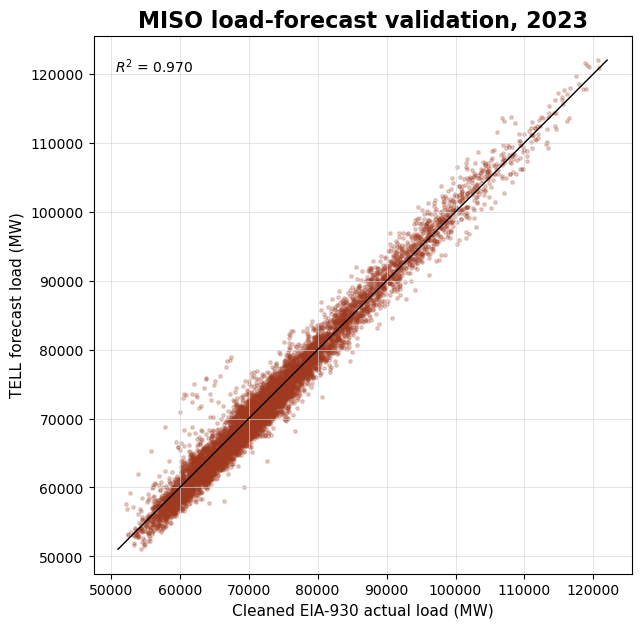

In [14]:
# Shared appearance for this notebook's figures.
plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "normal",
    "axes.labelsize": 11, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 9, "legend.frameon": False,
    "grid.color": "#d1d5db", "grid.linewidth": 0.7, "grid.alpha": 0.65,
    "figure.titlesize": 16, "figure.titleweight": "bold",
})

scatter_limits = [
    validation[["actual_load_mw", "forecast_load_mw"]].min().min(),
    validation[["actual_load_mw", "forecast_load_mw"]].max().max(),
]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(
    validation["actual_load_mw"],
    validation["forecast_load_mw"],
    s=6,
    alpha=0.24,
    color="#9f3a20",
    rasterized=True,
)
ax.plot(scatter_limits, scatter_limits, color="black", linewidth=1)
ax.text(0.04, 0.96, f"$R^2$ = {r2:.3f}", transform=ax.transAxes, va="top")
ax.set_xlabel("Cleaned EIA-930 actual load (MW)")
ax.set_ylabel("TELL forecast load (MW)")
ax.set_title(f"{BA_CODE} load-forecast validation, {VALIDATION_YEAR}", fontsize=16, fontweight="bold")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)
fig.tight_layout()
scatter_path = OUTPUT_DIR / "MISO_2023_tell_actual_vs_forecast_scatter.png"
fig.savefig(scatter_path, dpi=200, bbox_inches="tight")
plt.show()


### January 2023 load time series

Plot one readable month in local Central time using the same actual-versus-modeled load style as the MISO wind, solar, and load validation notebook.


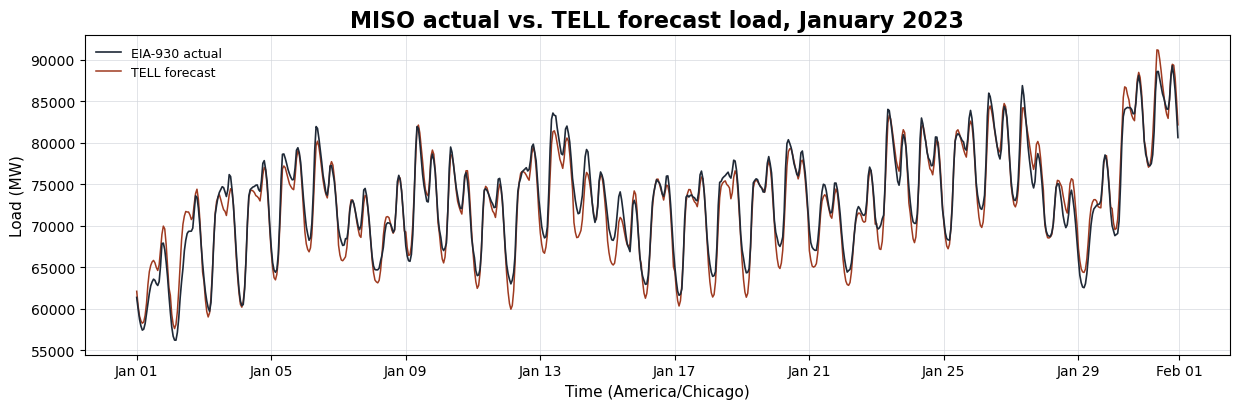

In [15]:
validation_local = validation.set_index("time_utc").tz_convert(LOCAL_TIMEZONE)
january_validation = validation_local.loc[f"{VALIDATION_YEAR}-01"]

fig, ax = plt.subplots(figsize=(12.5, 4.2))
ax.plot(
    january_validation.index,
    january_validation["actual_load_mw"],
    color="#1f2937",
    linewidth=1.2,
    label="EIA-930 actual",
    zorder=3,
)
ax.plot(
    january_validation.index,
    january_validation["forecast_load_mw"],
    color="#9f3a20",
    linewidth=1.1,
    label="TELL forecast",
)
ax.set_ylabel("Load (MW)")
ax.set_xlabel(f"Time ({LOCAL_TIMEZONE})")
ax.set_title(
    f"{BA_CODE} actual vs. TELL forecast load, January 2023", fontsize=16, fontweight="bold"
)
ax.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)
ax.legend(loc="upper left", frameon=False)
ax.xaxis.set_major_locator(
    mdates.DayLocator(bymonthday=range(1, 32, 4), tz=LOCAL_TIMEZONE)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %d", tz=LOCAL_TIMEZONE)
)
fig.tight_layout()
timeseries_path = OUTPUT_DIR / "MISO_20230101_20230131_tell_load_validation.png"
fig.savefig(timeseries_path, dpi=200, bbox_inches="tight")
plt.show()


## Interpretation

The validation compares this notebook-generated forecast with held-out 2023 cleaned actual load. MAE and RMSE describe error magnitude, bias shows its direction, and R-squared measures fit relative to variation in actual load. These values validate the reconstructed model; they are not a byte-for-byte check of the deposited load archive.